# Convolutional Neural Network (CNN) model architecture

## import library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2 as cv
import re
import requests
import csv
import tensorflow as tf
import math
import random


from sklearn.metrics import confusion_matrix,  multilabel_confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

from keras.utils import img_to_array
from keras.models import Sequential
from keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from keras.layers import BatchNormalization, Activation, Dropout
from keras.callbacks import ModelCheckpoint , EarlyStopping
from keras.utils import Sequence

In [2]:
import sys
print("python version :",sys.version)
print("tensorflow version :",tf.__version__)


python version : 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:45:18) [GCC 12.3.0]
tensorflow version : 2.16.1


## Sequence class for data load

In [3]:
from typing import Tuple

class Dataset(Sequence):
    def __init__(self, paths: str, batch_size: int,input_shape:Tuple[int,int,int]):
        super(Dataset, self).__init__()
        self.batch_size = batch_size
        self.__data = paths
        self.classes = []
        self.image_size=input_shape
        self.__labels = self.__list_labels(self.__data)



    def __len__(self):
        return math.ceil(len(self.__data) / self.batch_size)

    def __getitem__(self, idx):
        batch_x = self.__data[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.__labels[idx * self.batch_size:(idx + 1) * self.batch_size]
        return np.array([self.__load_image(i) for i in batch_x]), np.array(batch_y)

    def __list_labels(self, paths: list):
        labels = []
        for path in paths:
            #label = path.split(os.path.sep)[-2].split('_')
            label = path.split(os.path.sep)[-2].split(' ')
            labels.append(label)

        mlb = MultiLabelBinarizer()
        labels = mlb.fit_transform(labels)
        self.classes = mlb.classes_

        return labels

    @staticmethod
    def __load_image(path: str):
        img = cv.imread(path)
        img = cv.resize(img, (input_shape[0],input_shape[1]))
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        return img / 255.0

## **split Training and testing path**

In [4]:
train_size = 0.8
paths = []
path_to_subset = '/kaggle/input/cucumber-leaf-disease-dataset/cucumber_Leaf_Disease/train'
for folder in os.listdir(path_to_subset):

    for image in os.listdir(os.path.join(path_to_subset, folder)):
        path_to_image = os.path.join(path_to_subset, folder, image)

        #check image none or not none
        img = cv.imread(path_to_image)
        if img is not None:
          paths.append( path_to_image)

paths = sorted(paths)
paths[0]
random.shuffle(paths)
assert 0.0 < train_size <= 1.0
thresh = round(len(paths) * train_size)
train_paths = paths[:thresh]
test_paths = paths[thresh:]
print(train_paths[0], test_paths[1])

/kaggle/input/cucumber-leaf-disease-dataset/cucumber_Leaf_Disease/train/Healthy_leaves/IMG_2679.JPG /kaggle/input/cucumber-leaf-disease-dataset/cucumber_Leaf_Disease/train/Powdery_mildew/IMG_7922.JPG


In [5]:
print(len(paths))
print(f"Training image path length {len(train_paths) }, Validation image path length {len(test_paths) }")

3703
Training image path length 2962, Validation image path length 741


## **Model architecture**

In [6]:
def CNN_model(input_shape,len_class:int):
  model = tf.keras.models.Sequential()

  model.add(Conv2D(32, 3, padding = 'same', input_shape = input_shape, kernel_initializer = 'he_normal', activation = 'relu'))
  model.add(BatchNormalization()) #Stack of images become stack with no negative values
  model.add(MaxPooling2D(2))
  model.add(Dropout(0.25))

  model.add(Conv2D(64, 3, padding = 'same', kernel_initializer = 'he_normal', activation = 'relu'))
  model.add(BatchNormalization())
  model.add(Conv2D(64, 3, padding = 'same', kernel_initializer = 'he_normal', activation = 'relu'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D())
  model.add(Dropout(0.25))

  model.add(Conv2D(128, 3, padding = 'same', kernel_initializer = 'he_normal', activation = 'relu'))
  model.add(BatchNormalization())
  model.add(Conv2D(128, 2, padding = 'same', kernel_initializer = 'he_normal', activation = 'relu'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D())
  model.add(Dropout(0.25))

  model.add(Conv2D(256, 3, padding = 'same', kernel_initializer = 'he_normal', activation = 'relu'))
  model.add(BatchNormalization())
  model.add(Conv2D(256, 2, padding = 'same', kernel_initializer = 'he_normal', activation = 'relu'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D())
  model.add(Dropout(0.25))

  model.add(Conv2D(1024, 3, padding = 'same', kernel_initializer = 'he_normal', activation = 'relu'))
  model.add(BatchNormalization())
  model.add(Conv2D(1024, 2, padding = 'same', kernel_initializer = 'he_normal', activation = 'relu'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D())
  model.add(Dropout(0.25))



  model.add(Flatten())
  model.add(Dense(4096, activation = 'relu', kernel_initializer = 'he_normal', ))
  model.add(BatchNormalization())
  model.add(Dropout(0.5))

  model.summary()
  model.add(Dense(len_class, activation = 'softmax'))
  return model

## **Define model checkpoints to save best model**

In [7]:
# Define the directory and filename for saving the best model
model_filename = 'CLD_CNN.keras'

# Combine the directory and filename
model_path = model_filename

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)

In [8]:
best_weights = ModelCheckpoint('CLD_CNN.weights.h5',
                               monitor='val_loss',
                               verbose=0,
                               save_weights_only=True,
                               save_best_only=True,
                               mode='min',
                               save_freq='epoch')


last_weights = ModelCheckpoint('CLD_CNN.weights.h5',
                               monitor='val_loss',
                               verbose=0,
                               save_weights_only=True,
                               save_best_only=False,
                               mode='auto',
                               save_freq='epoch')

# Define EarlyStopping and ModelCheckpoint callbacks
early_stopping_callback = EarlyStopping(monitor='val_loss',
                                       patience=10,
                                       restore_best_weights=True,
                                       verbose=1)

## **Define Dataset class instance and compile CNN model**

In [9]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)

input_shape = (224,224, 3)
batch_size=32

train_ds = Dataset(train_paths,batch_size=batch_size,input_shape=input_shape)
test_ds = Dataset(test_paths,batch_size=batch_size,input_shape=input_shape)

len_class=3

model_CNN = CNN_model(input_shape,len_class)
model_CNN.compile(loss="CategoricalCrossentropy",
             optimizer="adam",
             metrics=['accuracy'])

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 212,862,336 (812.01 MB)

 Trainable params: 212,848,192 (811.95 MB)

 Non-trainable params: 14,144 (55.25 KB)

In [10]:
#save class
for i in range(len(train_ds.classes)):
    classes= '\n'.join(train_ds.classes)

with open('classes.txt', 'w') as f:
    f.write(classes)

#save model architectue as jason format

architecture_json = model_CNN.to_json()

with open('model_architecture_CNN.json', 'w') as json_file:
    json_file.write(architecture_json)


print(train_ds.classes)

['Downy_mildew' 'Healthy_leaves' 'Powdery_mildew']


In [11]:
with tf.device('/GPU:0'):
  history = model_CNN.fit(x=train_ds,
                      validation_data=test_ds,
                      epochs = 50,
                      callbacks = [checkpoint,best_weights,early_stopping_callback],
                      verbose = 1)

Epoch 1/50


I0000 00:00:1728546344.509627      66 service.cc:145] XLA service 0x7abb9800fde0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728546344.509718      66 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 1/93 ━━━━━━━━━━━━━━━━━━━━ 44:02 29s/step - accuracy: 0.4688 - loss: 1.3596

I0000 00:00:1728546363.891832      66 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_4', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1728546363.915927      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


29/93 ━━━━━━━━━━━━━━━━━━━━ 52s 815ms/step - accuracy: 0.7549 - loss: 1.7849

I0000 00:00:1728546386.743847      65 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_4', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_divide_multiply_subtract_fusion', 4 bytes spill stores, 4 bytes spill loads



93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8162 - loss: 1.2072
Epoch 1: val_loss improved from inf to 2.55065, saving model to CLD_CNN.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 91s 675ms/step - accuracy: 0.8168 - loss: 1.2019 - val_accuracy: 0.4912 - val_loss: 2.5506
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9263 - loss: 0.2269
Epoch 2: val_loss improved from 2.55065 to 1.54224, saving model to CLD_CNN.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 56s 586ms/step - accuracy: 0.9263 - loss: 0.2272 - val_accuracy: 0.4413 - val_loss: 1.5422
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9371 - loss: 0.1917
Epoch 3: val_loss did not improve from 1.54224
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 290ms/step - accuracy: 0.9372 - loss: 0.1916 - val_accuracy: 0.3644 - val_loss: 3.8797
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9533 - loss: 0.1450
Epoch 4: val_loss did not improve from 1.54224
93/93 ━━━━━━━━━━━━━━━━━━━━ 28s 284ms/step - accuracy: 0.953

## **CNN Training statics**

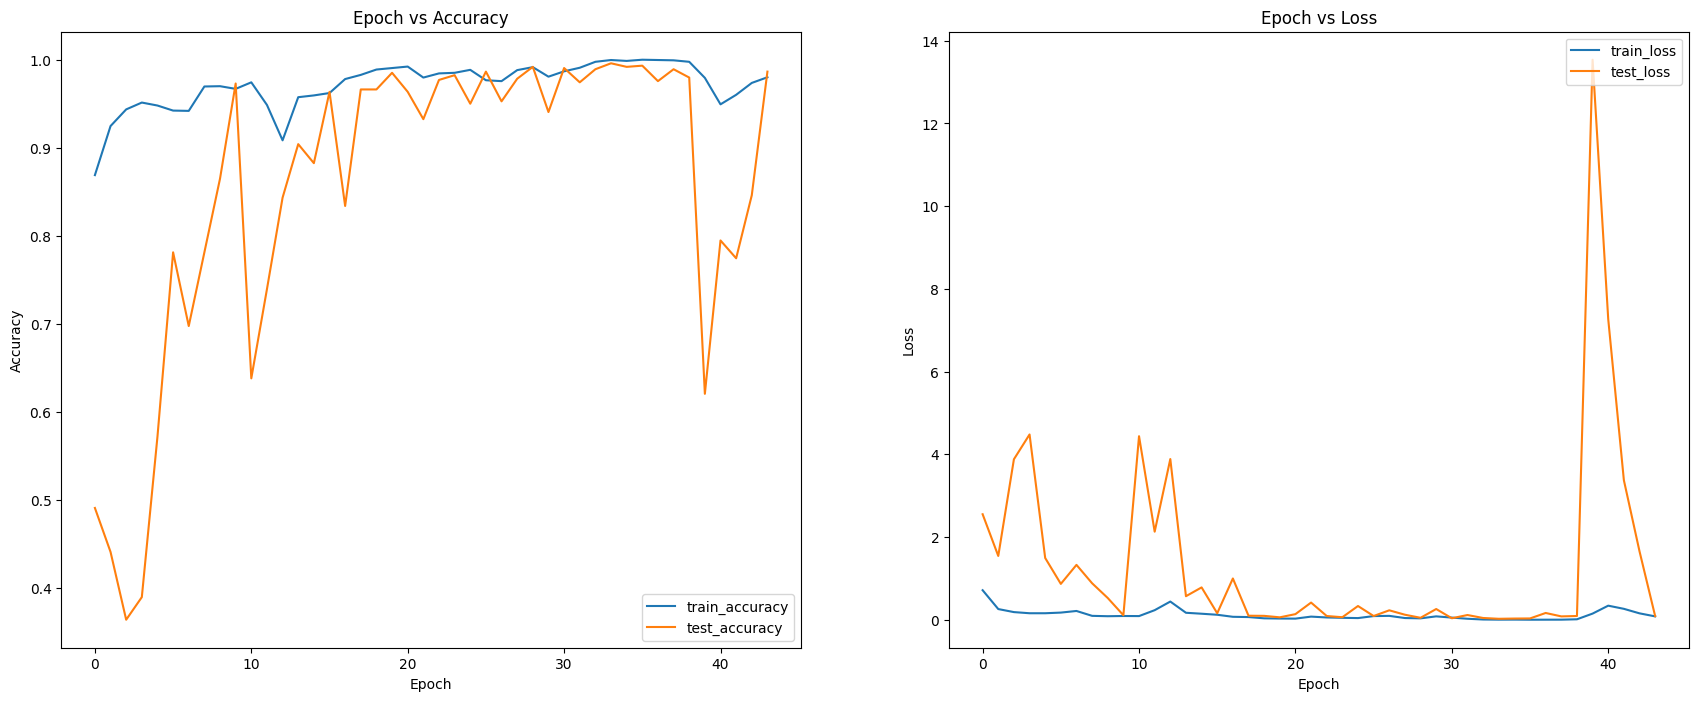

In [12]:
plt.figure(figsize=(21, 8))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='test_accuracy')
plt.title("Epoch vs Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')


plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='train_loss')
plt.plot(history.history["val_loss"], label='test_loss')
plt.title("Epoch vs Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

**Model evaluation**

In [13]:
test_paths = []
path_to_subset = '/kaggle/input/cucumber-leaf-disease-dataset/cucumber_Leaf_Disease/test'
for folder in os.listdir(path_to_subset):

    for image in os.listdir(os.path.join(path_to_subset, folder)):
        path_to_image = os.path.join(path_to_subset, folder, image)

        #check image none or not none
        img = cv.imread(path_to_image)
        if img is not None:
          test_paths.append( path_to_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━

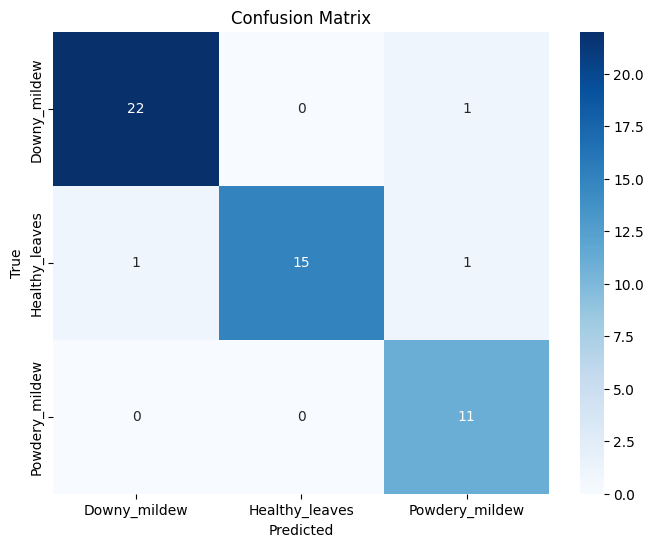

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1]


In [14]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluation(model,test_paths):
    Real_labels=[]
    prdict_label=[]

    for i, image_path in enumerate(test_paths):
        image=cv.imread(image_path)
        # Reading image, convert it to np array and decode
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        # Resize, scale and reshape image before making predictions
        resized = cv.resize(image, (input_shape[0],input_shape[1]))
        resized = (resized / 255.0).reshape(-1, input_shape[1], input_shape[0], input_shape[2])


        classes={'Downy_mildew':0 ,'Healthy_leaves':1, 'Powdery_mildew':2}

        label = image_path.split(os.path.sep)[-2].split(' ')
        Real_labels.append(classes[f"{label[0]}"])


        # Predict results
        preds = model.predict(resized)
        indices = np.argmax(preds, axis=1)
        prdict_label.append(indices[0])
        
    # Generate classification report
    report = classification_report(Real_labels,prdict_label, target_names=['Downy_mildew','Healthy_leaves','Powdery_mildew'])
    print(report)

    # Compute confusion matrix
    cm = confusion_matrix(Real_labels,prdict_label)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Downy_mildew','Healthy_leaves','Powdery_mildew'], yticklabels=['Downy_mildew','Healthy_leaves','Powdery_mildew'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


        
        
    return Real_labels , prdict_label


Real_labels,prdict_label=evaluation(model_CNN,test_paths)
print(Real_labels)
print(prdict_label)

## **Model inference**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Downy_mildew
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Powdery_mildew
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Downy_mildew
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Healthy_leaves
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Healthy_leaves
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Powdery_mildew


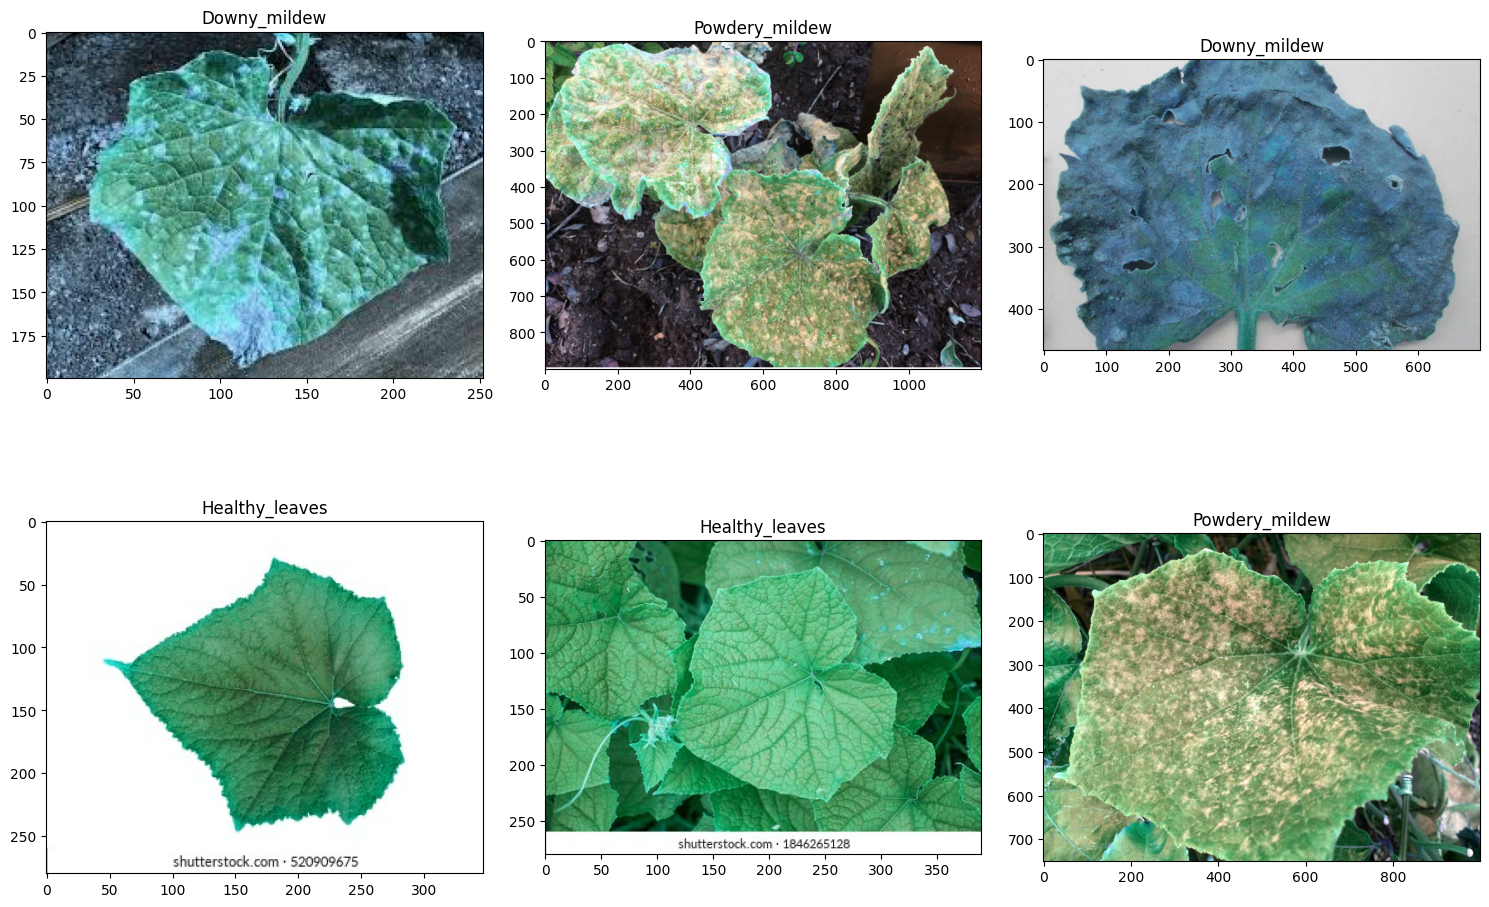

In [15]:
import cv2

# URLs to images
urls = [
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRKWUtKGe5jbDyat4Xk523pQkqS1HWPAXHrLg&s","https://images.saymedia-content.com/.image/t_share/MTc0MzU0NDg3NTYwMDU0MTIw/plant-diseases-that-affect-cucumbers-and-how-to-treat-them.jpg",
    "https://ipm.missouri.edu/MEG/2019/8/cucumberDownyMildew/necroticLesion.jpg",
    "https://www.shutterstock.com/image-photo/leaf-cucumber-closeup-isolated-on-260nw-520909675.jpg",
    "https://www.shutterstock.com/image-photo/close-cucumber-leaves-garden-260nw-1846265128.jpg",
    "https://plantvillage-production-new.s3.amazonaws.com/image/100322/file/default-9e39cd1faa62d5ce010e00c80006977b.jpg"  
]

fig = plt.figure(figsize = (15, 15))

for i, url in enumerate(urls):
    plt.subplot(331 + i)

    # Sending request to the URL
    r = requests.get(url, stream = True).raw

    # Reading image, convert it to np array and decode
    image = np.asarray(bytearray(r.read()), dtype="uint8")
    image = cv2.imdecode(image, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    #image = img_to_array(image)


    # Resize, scale and reshape image before making predictions
    resized = cv2.resize(image, (input_shape[0],input_shape[1]))
    resized = (resized / 255.0).reshape(-1, input_shape[1], input_shape[0], input_shape[2])

    classes={0:'Downy_mildew',1:'Healthy_leaves',2:'Powdery_mildew'}
    
    # Predict results
    preds = model_CNN.predict(resized)
    indices = np.argmax(preds, axis=1)
    prdict_label=(classes[indices[0]])
    print(prdict_label)


    # Showing image
    plt.imshow(image[:, :, ::-1])
    plt.title(f'{prdict_label}')

plt.tight_layout()